In [34]:
import pandas as pd

## Cargar archivos en daoPlotter
dataSource = 'ResultsScenarios/'
nScenarios = 5

scenario_data = {}
mean_values = []

for i in range(1, nScenarios + 1):
    filePath = f'{dataSource}Scenario{i}.txt'
    
    with open(filePath, 'r') as file:
        data = file.readlines()
        # Procesar los datos según sea necesario
        print(f'Contenido del archivo Scenario{i}.txt:')
        n_line = 0
        value_list = []
        n_aperture_list = []
        bot_list = []
        for line in data:
            line = line.replace(',', '.')
            values = line.strip().split(' ')
            # Aquí puedes agregar más lógica para procesar cada línea si es necesario
            if(n_line != 0):
                value_list.append(float(values[0]))
                n_aperture_list.append(int(values[1]))
                bot_list.append(float(values[2]))
            n_line += 1

        # Create dataframe from lists
        df = pd.DataFrame({
            'Value': value_list,
            'N_Aperture': n_aperture_list,
            'Bot': bot_list
        })

        scenario_data[f'Scenario{i}'] = df

        mean_value = df['Value'].mean()
        mean_values.append(mean_value)

mean_values

Contenido del archivo Scenario1.txt:
Contenido del archivo Scenario2.txt:
Contenido del archivo Scenario3.txt:
Contenido del archivo Scenario4.txt:
Contenido del archivo Scenario5.txt:


[80.33100000000002,
 80.33100000000002,
 79.8455,
 115.62950000000001,
 114.87449999999998]

In [35]:
# importar robustity.txt desde dataPlotter
robustness_file = f'{dataSource}Robustity.txt'
ScenariosResults = []
with open(robustness_file, 'r') as file:
    robustness_data = file.readlines()
    print('Contenido del archivo robustness.txt:')
    for line in robustness_data:
        if(line.strip() == ''):
            continue  # Saltar la línea de encabezado
        best_fit, n_aper, bot, overScenarios = line.strip().split(' ')
        # Transformar la lista de string OverScenarios en una lista de flotantes
        overScenarios = overScenarios.replace('[', '').replace(']', '')
        overScenarios_list = [float(x) for x in overScenarios.split(',')]
        ScenariosResults.append(overScenarios_list)


ScenariosResults
average_Scenarios = []
for n in range(nScenarios):
    resultCurrentScenario = [ScenariosResults[i][n] for i in range(len(ScenariosResults))]
    print(f'Resultados para el escenario {n+1}: {resultCurrentScenario}')
    average_value = sum(resultCurrentScenario) / len(resultCurrentScenario)
    average_Scenarios.append(average_value)

average_Scenarios

Contenido del archivo robustness.txt:
Resultados para el escenario 1: [2737.5803446663167, 3276.442237412008, 3303.2497275746337, 2492.384624552485, 2486.3004741141044, 3124.7897529494358, 2001.489401823297, 4946.631654641454, 2733.785220184065, 2448.9193217313787, 3517.989592251701, 4938.6264583828415, 4440.704403663571, 2918.7399121474464, 3434.0382205669753, 2433.735565973505, 2656.646924669887, 3391.370013565011, 3499.083105434024, 3292.9797850429513]
Resultados para el escenario 2: [7404.117705849569, 7439.008252097235, 7425.991470148421, 7423.672689894562, 6800.83090704495, 6952.648763350727, 7437.526141724864, 7424.127979880423, 7428.551089515758, 7065.313687587022, 7426.731091607631, 7443.204279840721, 7413.928698559161, 7418.390720460748, 5527.16242335309, 7428.24886248339, 7417.673401566596, 7405.839275360971, 7405.975629891039, 7417.8753235433]
Resultados para el escenario 3: [7232.901931463288, 6878.838108023005, 7312.031315727815, 7300.4715046838355, 6391.383693831585, 692

[3203.774337067355,
 7255.340919688009,
 7037.9088106355775,
 5124.733734035447,
 5201.321745422737]

# Scenario Ideal

In [36]:

BestScenarioResults = [[65.34905165149857, 14670.177479822602, 13577.660436800064, 5640.21664764263, 4793.71345966638],
                       [63.64804071478157, 15044.67077667557, 13772.962580051662, 5051.074667122822, 4350.0476516503],
                       [62.52662862652316, 12607.865022768596, 11419.472137950828, 7174.591853675077, 6276.487604862397]]

# Average of BestScenarioResults
average_BestScenario = []

for n in range(nScenarios):
    resultCurrentScenario = [BestScenarioResults[i][n] for i in range(len(BestScenarioResults))]
    print(f'Resultados para el escenario {n+1}: {resultCurrentScenario}')
    average_value = sum(resultCurrentScenario) / len(resultCurrentScenario)
    average_BestScenario.append(average_value)

print('Average Best Scenario Results:', average_BestScenario)

Resultados para el escenario 1: [65.34905165149857, 63.64804071478157, 62.52662862652316]
Resultados para el escenario 2: [14670.177479822602, 15044.67077667557, 12607.865022768596]
Resultados para el escenario 3: [13577.660436800064, 13772.962580051662, 11419.472137950828]
Resultados para el escenario 4: [5640.21664764263, 5051.074667122822, 7174.591853675077]
Resultados para el escenario 5: [4793.71345966638, 4350.0476516503, 6276.487604862397]
Average Best Scenario Results: [63.84124033093443, 14107.571093088924, 12923.365051600851, 5955.294389480176, 5140.082905393026]


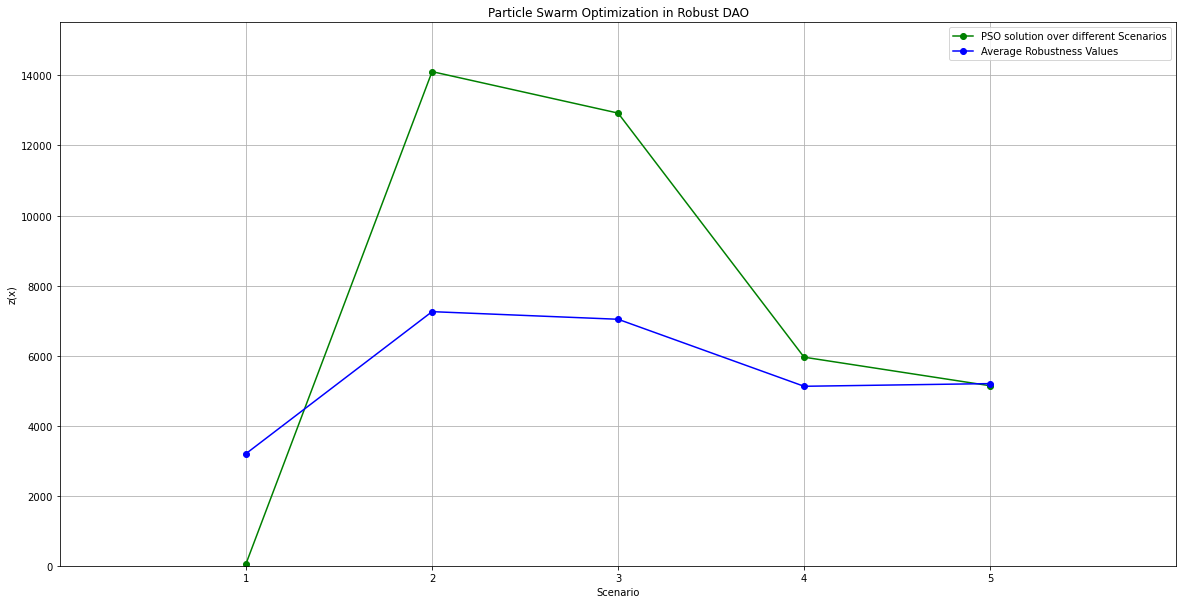

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(range(1, nScenarios + 1), average_BestScenario, marker='o', color='green')

# Incluir la lista average_Scenarios en la gráfica
plt.plot(range(1, nScenarios + 1), average_Scenarios, marker='o', color='blue')
plt.legend(['PSO solution over different Scenarios', 'Average Robustness Values'])


plt.title('Particle Swarm Optimization in Robust DAO')
plt.xlabel('Scenario')
plt.ylabel('z(x)')

plt.ylim(0, max(max(average_BestScenario), max(average_Scenarios)) * 1.1)
plt.xlim(0, nScenarios + 1)

plt.xticks(range(1, nScenarios + 1))
plt.grid(True)
plt.show()

# Scenario 2

Resultados para el escenario 1: [2642.2642103546546]
Resultados para el escenario 2: [82.2340459433836]
Resultados para el escenario 3: [14036.175518621596]
Resultados para el escenario 4: [4602.744193304555]
Resultados para el escenario 5: [2438.8040842333253]


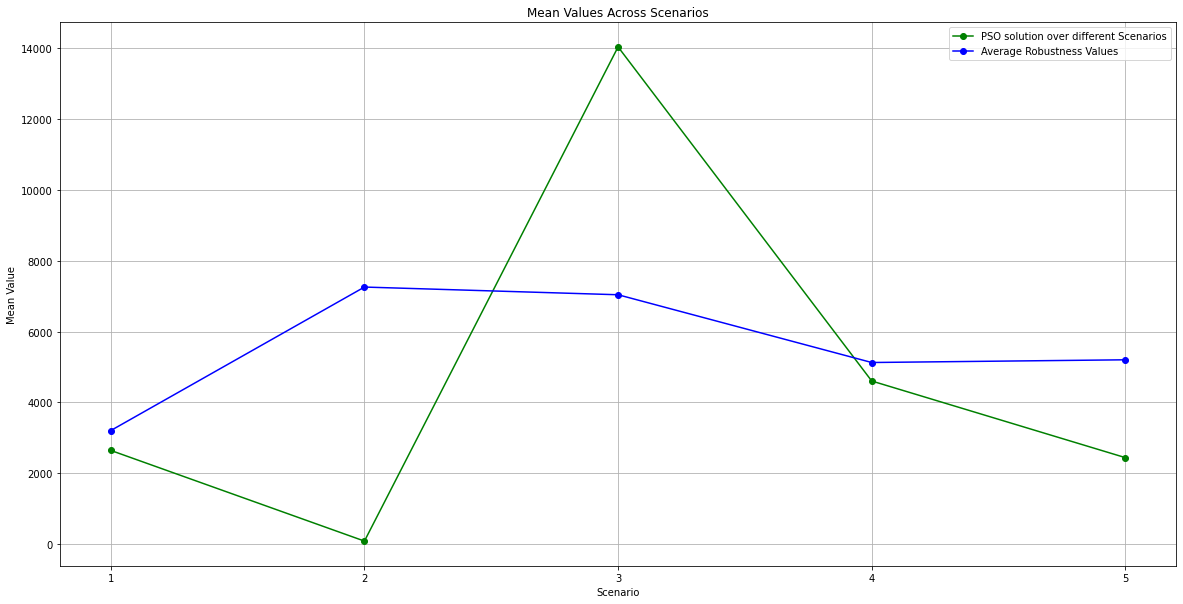

Average Best Scenario Results: [2642.2642103546546, 82.2340459433836, 14036.175518621596, 4602.744193304555, 2438.8040842333253]


In [38]:
BestScenarioResults = [[2642.2642103546546, 82.2340459433836, 14036.175518621596, 4602.744193304555, 2438.8040842333253]]

# Average of BestScenarioResults
average_BestScenario = []

for n in range(nScenarios):
    resultCurrentScenario = [BestScenarioResults[i][n] for i in range(len(BestScenarioResults))]
    print(f'Resultados para el escenario {n+1}: {resultCurrentScenario}')
    average_value = sum(resultCurrentScenario) / len(resultCurrentScenario)
    average_BestScenario.append(average_value)

plt.figure(figsize=(20, 10))
plt.plot(range(1, nScenarios + 1), average_BestScenario, marker='o', color='green')

# Incluir la lista average_Scenarios en la gráfica
plt.plot(range(1, nScenarios + 1), average_Scenarios, marker='o', color='blue')
plt.legend(['PSO solution over different Scenarios', 'Average Robustness Values'])


plt.title('Mean Values Across Scenarios')
plt.xlabel('Scenario')
plt.ylabel('Mean Value')
plt.xticks(range(1, nScenarios + 1))
plt.grid(True)
plt.show()
print('Average Best Scenario Results:', average_BestScenario)

# Scenario 3

Resultados para el escenario 1: [393.74123072829104, 586.0237395123033]
Resultados para el escenario 2: [8120.765137380617, 9528.469797137555]
Resultados para el escenario 3: [87.07232291600519, 76.24772568856068]
Resultados para el escenario 4: [14002.68085020901, 14403.768615530684]
Resultados para el escenario 5: [12747.644636617693, 11210.29492586697]


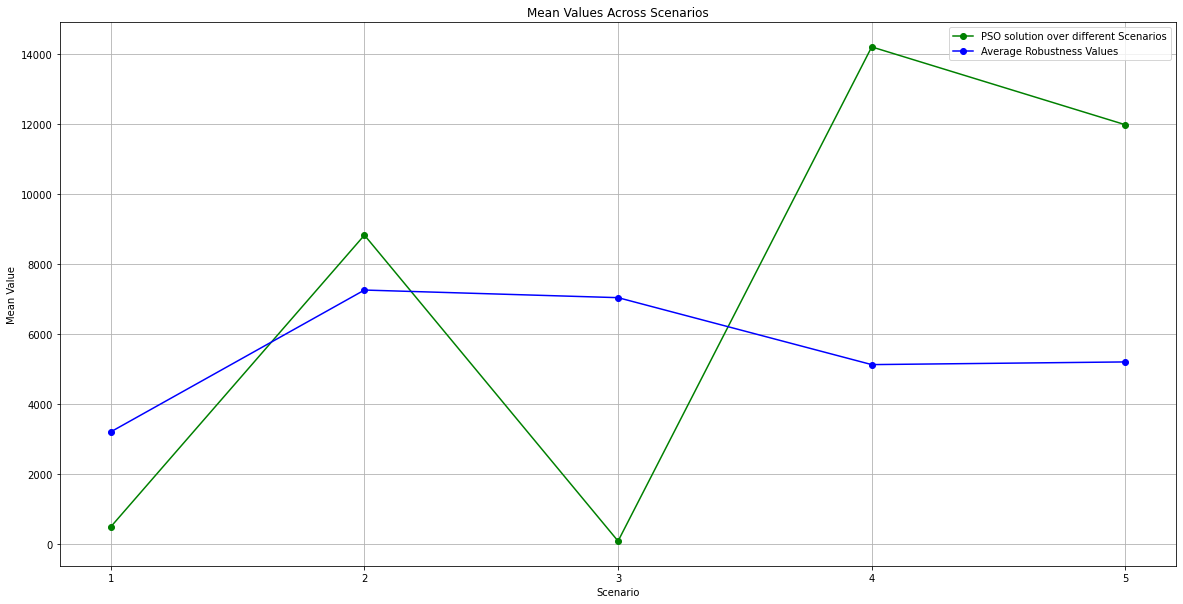

Average Best Scenario Results: [489.8824851202972, 8824.617467259086, 81.66002430228293, 14203.224732869847, 11978.969781242333]


In [39]:
BestScenarioResults = [[393.74123072829104, 8120.765137380617, 87.07232291600519, 14002.68085020901, 12747.644636617693],
                       [586.0237395123033, 9528.469797137555, 76.24772568856068, 14403.768615530684, 11210.29492586697]]



# Average of BestScenarioResults
average_BestScenario = []

for n in range(nScenarios):
    resultCurrentScenario = [BestScenarioResults[i][n] for i in range(len(BestScenarioResults))]
    print(f'Resultados para el escenario {n+1}: {resultCurrentScenario}')
    average_value = sum(resultCurrentScenario) / len(resultCurrentScenario)
    average_BestScenario.append(average_value)

plt.figure(figsize=(20, 10))
plt.plot(range(1, nScenarios + 1), average_BestScenario, marker='o', color='green')

# Incluir la lista average_Scenarios en la gráfica
plt.plot(range(1, nScenarios + 1), average_Scenarios, marker='o', color='blue')
plt.legend(['PSO solution over different Scenarios', 'Average Robustness Values'])


plt.title('Mean Values Across Scenarios')
plt.xlabel('Scenario')
plt.ylabel('Mean Value')
plt.xticks(range(1, nScenarios + 1))
plt.grid(True)
plt.show()
print('Average Best Scenario Results:', average_BestScenario)

# Scenario 4

In [40]:
BestScenarioResults = []

# Average of BestScenarioResults
average_BestScenario = []

for n in range(nScenarios):
    resultCurrentScenario = [BestScenarioResults[i][n] for i in range(len(BestScenarioResults))]
    print(f'Resultados para el escenario {n+1}: {resultCurrentScenario}')
    average_value = sum(resultCurrentScenario) / len(resultCurrentScenario)
    average_BestScenario.append(average_value)

plt.figure(figsize=(20, 10))
plt.plot(range(1, nScenarios + 1), average_BestScenario, marker='o', color='green')

# Incluir la lista average_Scenarios en la gráfica
plt.plot(range(1, nScenarios + 1), average_Scenarios, marker='o', color='blue')
plt.legend(['PSO solution over different Scenarios', 'Average Robustness Values'])


plt.title('Mean Values Across Scenarios')
plt.ylim(0, 20000)
plt.xlabel('Scenario')
plt.ylabel('Mean Value')
plt.xticks(range(1, nScenarios + 1))
plt.grid(True)
plt.show()
print('Average Best Scenario Results:', average_BestScenario)

Resultados para el escenario 1: []


ZeroDivisionError: division by zero